# 2. Rep Segmentation

Detect individual push-up repetitions inside each video by analysing the **mean elbow-angle signal**.

```
mean_elbow_angle (raw)  →  moving-average smoothing  →  inverted signal
   ↓
scipy.signal.find_peaks  (distance + prominence tuning)
   ↓
Valley frames  →  valley[i] : valley[i+1]  =  one rep
   ↓
Rep segments saved to  feature_engineering/data/segments/
```

**Intuition:**  
- Elbow angle is **large (~160°) at the top** (arms extended) and **small (~70°) at the bottom** (chest near floor).  
- Each push-up bottom = a **valley** in the elbow-angle curve.  
- Inverting the signal (multiply by -1) turns valleys into peaks, so `find_peaks` can find them.

**Depends on:** `1.feature_engineering.ipynb` — feature JSONs in `feature_engineering/data/features/`

In [35]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.signal import find_peaks
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT     = Path('..').resolve()
FE_DIR   = ROOT / 'feature_engineering'
FEAT_DIR = FE_DIR / 'data' / 'features'
SEG_DIR  = FE_DIR / 'data' / 'segments'
SEG_DIR.mkdir(parents=True, exist_ok=True)

feat_files = sorted(FEAT_DIR.glob('*.json'))
print(f'Feature files found: {len(feat_files)}')

if not feat_files:
    raise FileNotFoundError('Run 1.feature_engineering.ipynb first.')

Feature files found: 152


## 2.1 Signal Smoothing

In [36]:

def adaptive_k(n_frames: int, k: int = 5) -> int:
    """
    Scale smoothing window to clip length.
    Very short clips get k=1 (no smoothing) to preserve every data point.
      n_frames < 10  → k=1
      n_frames < 20  → k=3
      otherwise      → k (default 5)
    """
    if n_frames < 10:
        return 1
    if n_frames < 20:
        return 3
    return k


def moving_average(sig: np.ndarray, k: int = 5) -> np.ndarray:
    """
    Edge-safe moving average via pandas rolling with center=True, min_periods=1.
    Unlike np.convolve(mode='same'), this never pads with zeros, so short clips
    keep their true edge values.
    """
    import pandas as pd
    k_use = adaptive_k(len(sig), k)
    if k_use <= 1:
        return sig.copy().astype(float)
    return (pd.Series(sig.astype(float))
              .rolling(k_use, center=True, min_periods=1)
              .mean()
              .to_numpy())


def smooth_elbow(feat_data: dict, k: int = 5) -> np.ndarray:
    raw = np.array([f['mean_elbow_angle'] for f in feat_data['features']])
    return moving_average(raw, k=k)


print('Smoothing helpers ready (edge-safe, adaptive k).')


Smoothing helpers ready (edge-safe, adaptive k).


## 2.2 Valley Detection — Tuning Parameters

Key `find_peaks` parameters (applied to the **inverted** signal):

| Parameter | Typical range | Meaning |
|---|---|---|
| `distance` | 15–30 | Min frames between two consecutive reps |
| `prominence` | 8–20 | Min depth of a valley relative to surroundings (°) |
| `height` | negative of max angle | Ignore shallow peaks |

Run the interactive comparison below to pick good defaults before bulk processing.

In [37]:

# ── Tunable defaults ──────────────────────────────────────────────────────────
# mean rep length in this dataset is ~11-13 frames, so keep distance low.
SMOOTH_K    = 5     # moving-average window
DISTANCE    = 8     # min frames between valleys  (was 20 — too large for short clips)
PROMINENCE  = 5     # min valley depth (degrees)  (was 10 — too strict for subtle angles)

# Adaptive fallback cascade: tried in order if the primary params find 0 valleys
FALLBACK_PARAMS = [
    dict(distance=8,  prominence=3),
    dict(distance=5,  prominence=2),
    dict(distance=3,  prominence=1),
]


def detect_valleys(elbow_smooth: np.ndarray,
                   distance: int   = DISTANCE,
                   prominence: float = PROMINENCE) -> np.ndarray:
    """
    Return frame indices of push-up bottom positions (valleys).
    Strategy: invert signal, find peaks.
    """
    inverted = -elbow_smooth
    valleys, _ = find_peaks(inverted,
                             distance   = distance,
                             prominence = prominence)
    return valleys


def detect_valleys_adaptive(elbow_smooth: np.ndarray,
                             distance: int   = DISTANCE,
                             prominence: float = PROMINENCE) -> tuple[np.ndarray, dict]:
    """
    Like detect_valleys but falls back to progressively looser params
    if the primary settings find nothing.
    Returns (valley_indices, params_used).
    """
    primary = dict(distance=distance, prominence=prominence)
    vlys = detect_valleys(elbow_smooth, **primary)
    if len(vlys) > 0:
        return vlys, primary

    for fb in FALLBACK_PARAMS:
        vlys = detect_valleys(elbow_smooth, **fb)
        if len(vlys) > 0:
            return vlys, fb

    return np.array([], dtype=int), primary   # genuinely empty signal


print('detect_valleys() and detect_valleys_adaptive() ready.')


detect_valleys() and detect_valleys_adaptive() ready.


## 2.3 Visualise Valley Detection on 4 Sample Videos

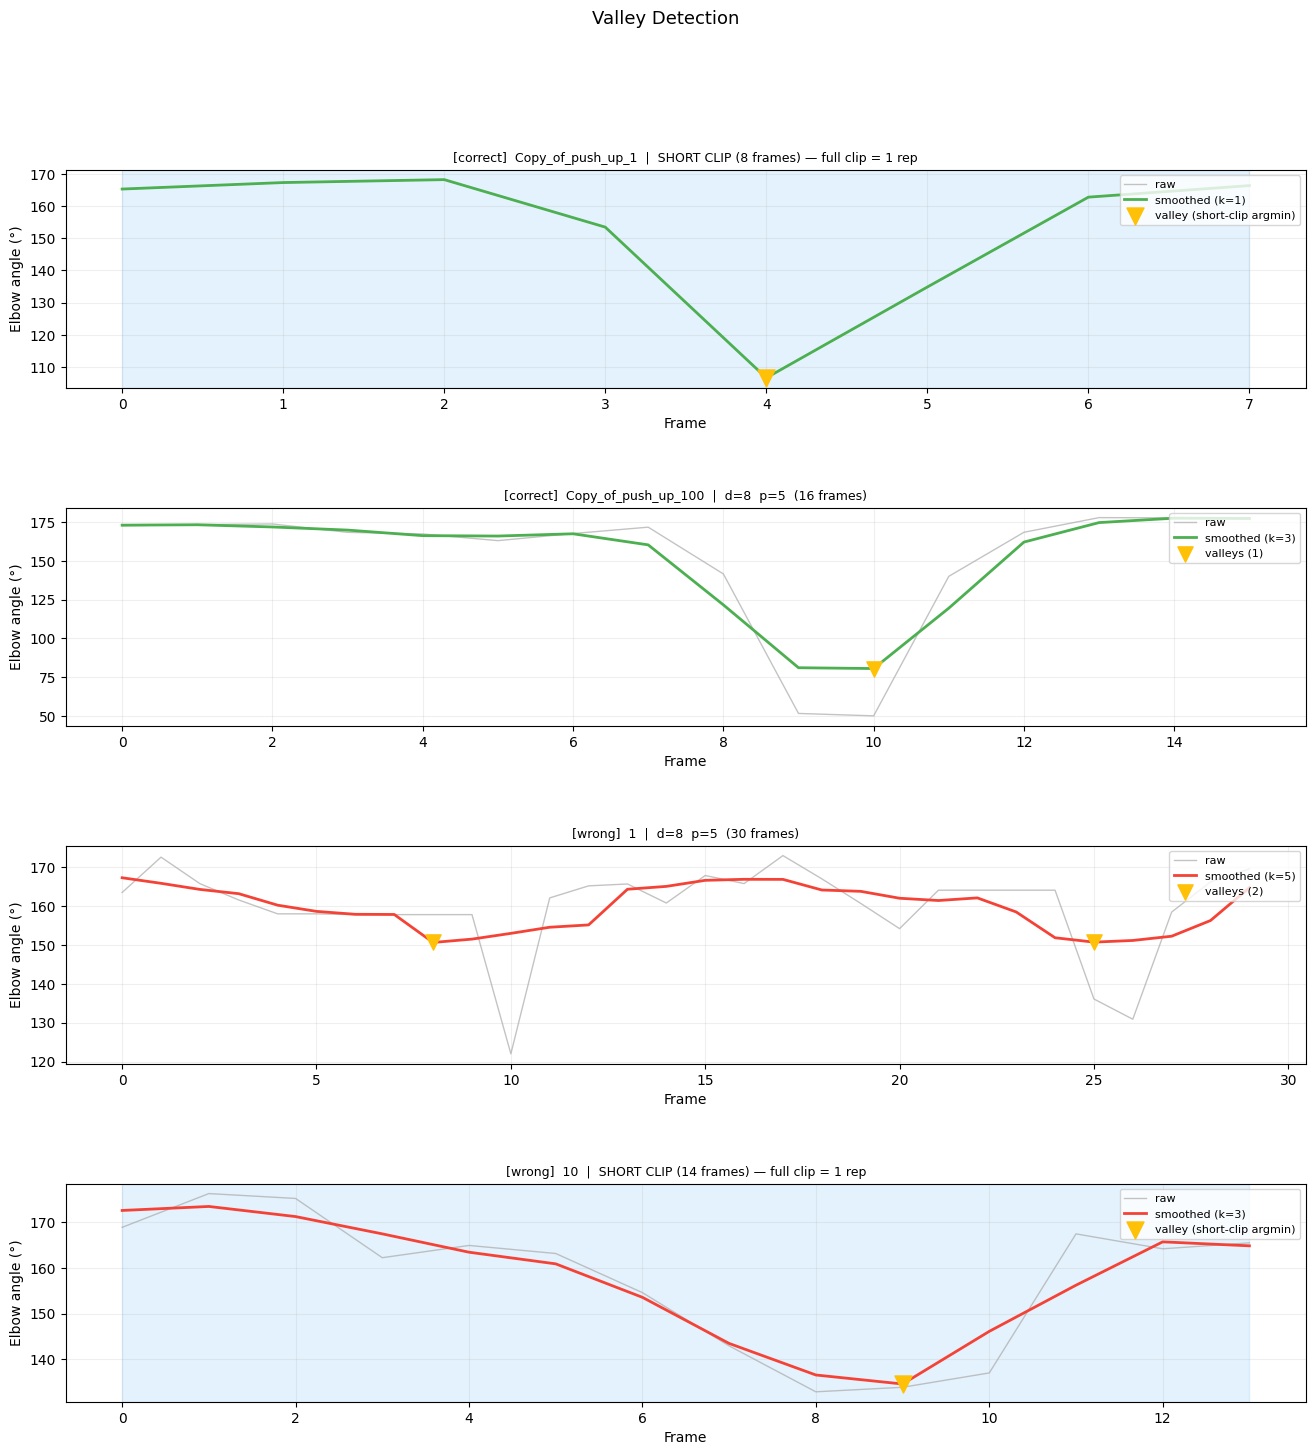

In [38]:

def load_features(path: Path) -> dict:
    return json.loads(path.read_text())


def plot_valley_detection(feat_files_sample, title='Valley Detection',
                          distance=DISTANCE, prominence=PROMINENCE, k=SMOOTH_K):
    n   = len(feat_files_sample)
    fig = plt.figure(figsize=(16, 4 * n))
    gs  = gridspec.GridSpec(n, 1, hspace=0.55)

    for i, jf in enumerate(feat_files_sample):
        vd    = load_features(jf)
        raw   = np.array([f['mean_elbow_angle'] for f in vd['features']])
        smo   = moving_average(raw, k=k)
        n_fr  = len(raw)
        color = '#4CAF50' if vd['label'] == 'correct' else '#F44336'
        ax    = fig.add_subplot(gs[i])

        ax.plot(raw, color='#AAA', lw=1, alpha=0.7, label='raw')
        ax.plot(smo, color=color,  lw=2, label=f'smoothed (k={adaptive_k(n_fr, k)})')

        if n_fr < SHORT_CLIP_THRESHOLD:
            # Short clip: mark the whole clip and the argmin
            sole = int(np.argmin(smo))
            ax.axvspan(0, n_fr - 1, alpha=0.12, color='#2196F3')
            ax.scatter([sole], [smo[sole]], color='#FFC107', s=150, zorder=5,
                       marker='v', label=f'valley (short-clip argmin)')
            method_str = f'SHORT CLIP ({n_fr} frames) — full clip = 1 rep'
        else:
            vlys, params_used = detect_valleys_adaptive(smo, distance=distance,
                                                         prominence=prominence)
            if len(vlys) == 0:
                vlys = np.array([int(np.argmin(smo))])
                params_used = {'distance': 'n/a', 'prominence': 'last-resort'}
            ax.scatter(vlys, smo[vlys], color='#FFC107', s=120, zorder=5,
                       marker='v', label=f'valleys ({len(vlys)})')
            method_str = (f'd={params_used["distance"]}  '
                          f'p={params_used["prominence"]}  '
                          f'({n_fr} frames)')

        ax.set_title(
            f'[{vd["label"]}]  {vd["video"]}  |  {method_str}',
            fontsize=9)
        ax.set_ylabel('Elbow angle (°)')
        ax.set_xlabel('Frame')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.2)

    fig.suptitle(title, fontsize=13)
    plt.show()


# Pick 2 correct + 2 wrong for inspection
correct_ffiles = [f for f in feat_files if json.loads(f.read_text())['label'] == 'correct']
wrong_ffiles   = [f for f in feat_files if json.loads(f.read_text())['label'] == 'wrong']

sample = (correct_ffiles[:2] + wrong_ffiles[:2])[:4]
plot_valley_detection(sample)


## 2.4 Adjust Parameters (if needed)

Run this cell to iterate on parameters, then re-run the plot above.

- **Too many valleys** → increase `PROMINENCE` or `DISTANCE`
- **Too few valleys** → decrease `PROMINENCE`
- **Fast pushups not caught** → decrease `DISTANCE`

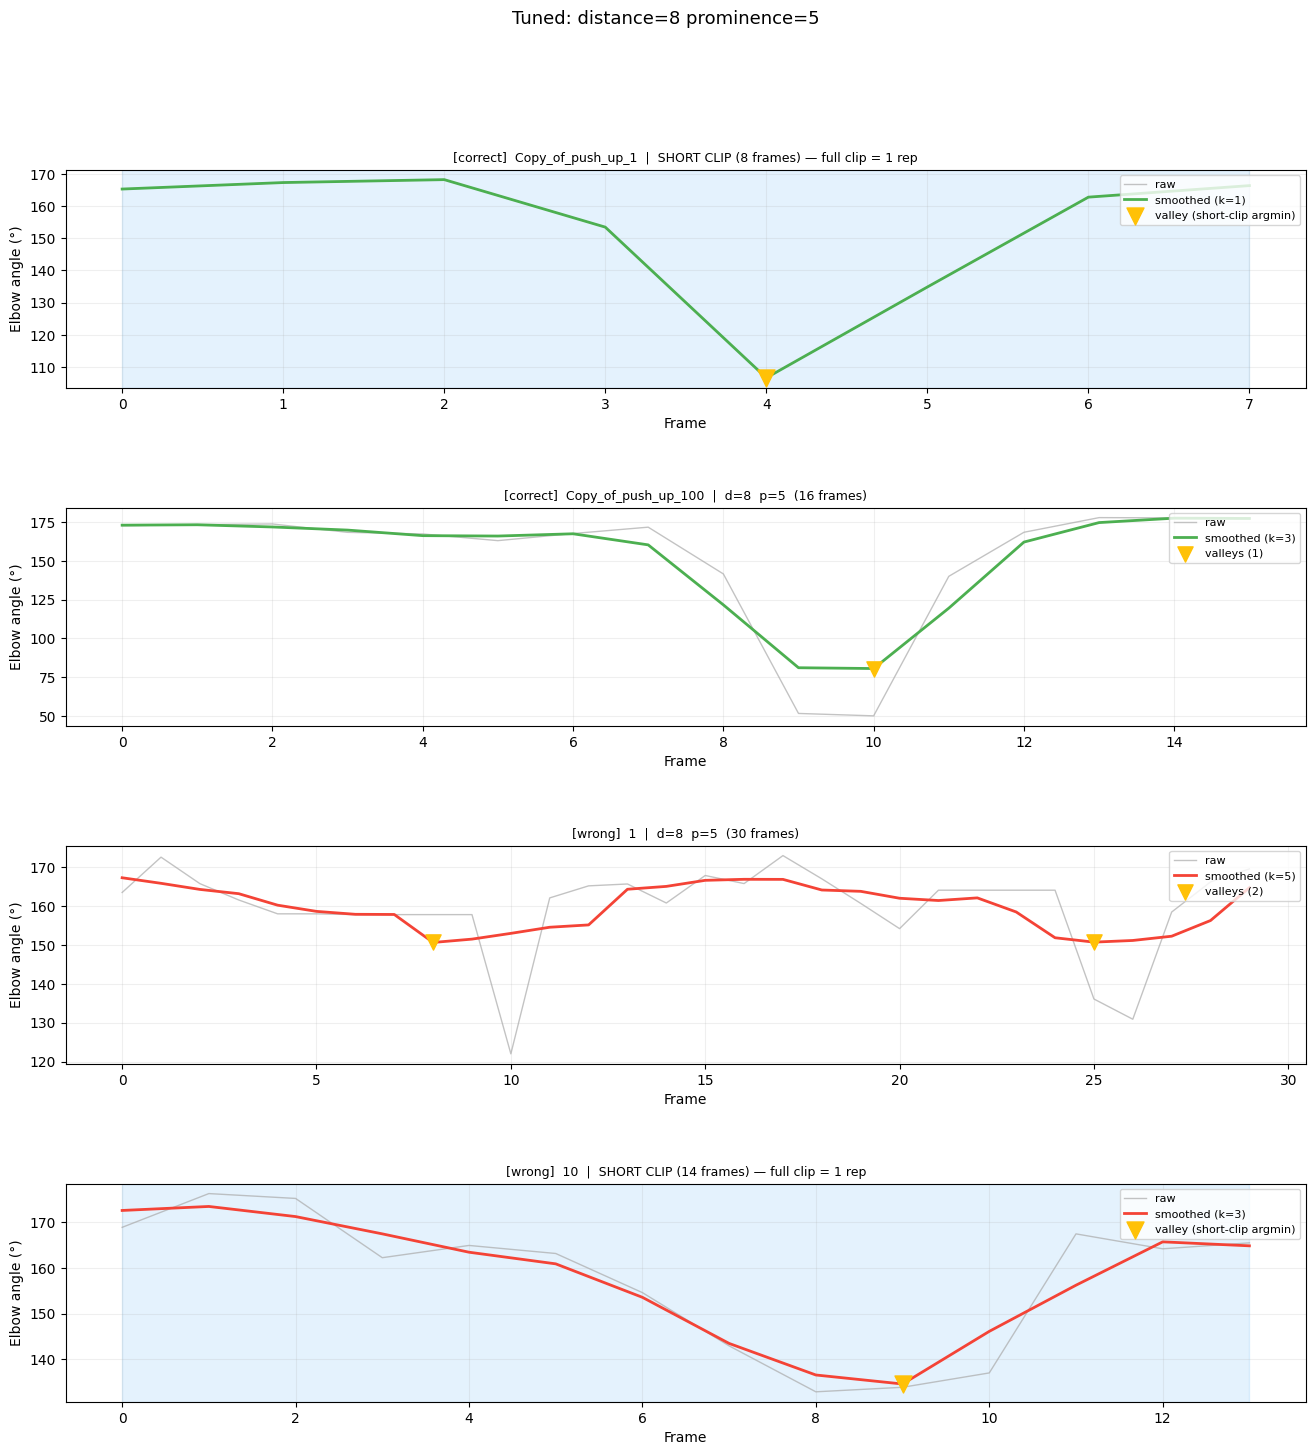

In [46]:

# ── Override parameters here and re-run the plot cell if needed ──────────────
SMOOTH_K   = 5
DISTANCE   = 8
PROMINENCE = 5

plot_valley_detection(sample,
                      title=f'Tuned: distance={DISTANCE} prominence={PROMINENCE}',
                      distance=DISTANCE, prominence=PROMINENCE, k=SMOOTH_K)


## 2.5 Rep Boundary Extraction

Strategy: each valley marks the **bottom of a rep**.  
A rep spans from the **midpoint before** the valley to the **midpoint after** it:

```
valleys = [v0, v1, v2, ...]
rep_i runs from  mid(v_prev, v_i)  →  mid(v_i, v_next)
```

This centres each segment on its valley for consistent context.

In [47]:

# Clips shorter than this skip find_peaks entirely and use the whole clip as 1 rep
SHORT_CLIP_THRESHOLD = 15


def extract_rep_segments(feat_data: dict,
                         distance: int     = DISTANCE,
                         prominence: float = PROMINENCE,
                         k: int            = SMOOTH_K,
                         padding: int      = 3) -> list[dict]:
    """
    Extract rep segments centred around each detected valley.

    Short clips (< SHORT_CLIP_THRESHOLD frames):
        → Entire clip treated as 1 rep, valley = argmin(smoothed).
          No find_peaks needed — avoids false negatives on 8-15 frame clips.

    Longer clips:
        → Adaptive valley detection with progressive fallback.
    """
    feats = feat_data['features']
    raw   = np.array([f['mean_elbow_angle'] for f in feats])
    smo   = moving_average(raw, k=k)
    n_fr  = len(feats)

    # ── Short clip fast path ──────────────────────────────────────────────────
    if n_fr < SHORT_CLIP_THRESHOLD:
        sole_valley = int(np.argmin(smo))
        # Use the full clip as one rep (padding clamped)
        start = 0
        end   = n_fr
        if end - start < 2:
            return []
        return [{
            'video'   : feat_data['video'],
            'label'   : feat_data['label'],
            'rep_idx' : 0,
            'start'   : start,
            'end'     : end,
            'valley'  : sole_valley,
            'length'  : end - start,
            'features': feats[start:end],
        }]

    # ── Normal path: adaptive valley detection ────────────────────────────────
    vlys, _ = detect_valleys_adaptive(smo, distance=distance, prominence=prominence)

    if len(vlys) == 0:
        # Final last resort: global minimum
        vlys = np.array([int(np.argmin(smo))])

    # Rep boundaries: midpoints between adjacent valleys
    # Sentinels: 0 at left, (n_fr - 1) at right
    extended = np.concatenate([[0], vlys, [n_fr - 1]])
    segments = []

    for rep_i, v in enumerate(vlys):
        prev_bound = extended[rep_i]
        next_bound = extended[rep_i + 2]

        start = max(0,    int((prev_bound + v) // 2) - padding)
        end   = min(n_fr, int((v + next_bound) // 2) + padding)

        if end - start < 3:
            continue

        segments.append({
            'video'   : feat_data['video'],
            'label'   : feat_data['label'],
            'rep_idx' : rep_i,
            'start'   : int(start),
            'end'     : int(end),
            'valley'  : int(v),
            'length'  : int(end - start),
            'features': feats[start:end],
        })

    return segments


print(f'extract_rep_segments() ready.  Short-clip threshold: {SHORT_CLIP_THRESHOLD} frames')


extract_rep_segments() ready.  Short-clip threshold: 15 frames


## 2.6 Visualise Rep Segments on a Sample Video

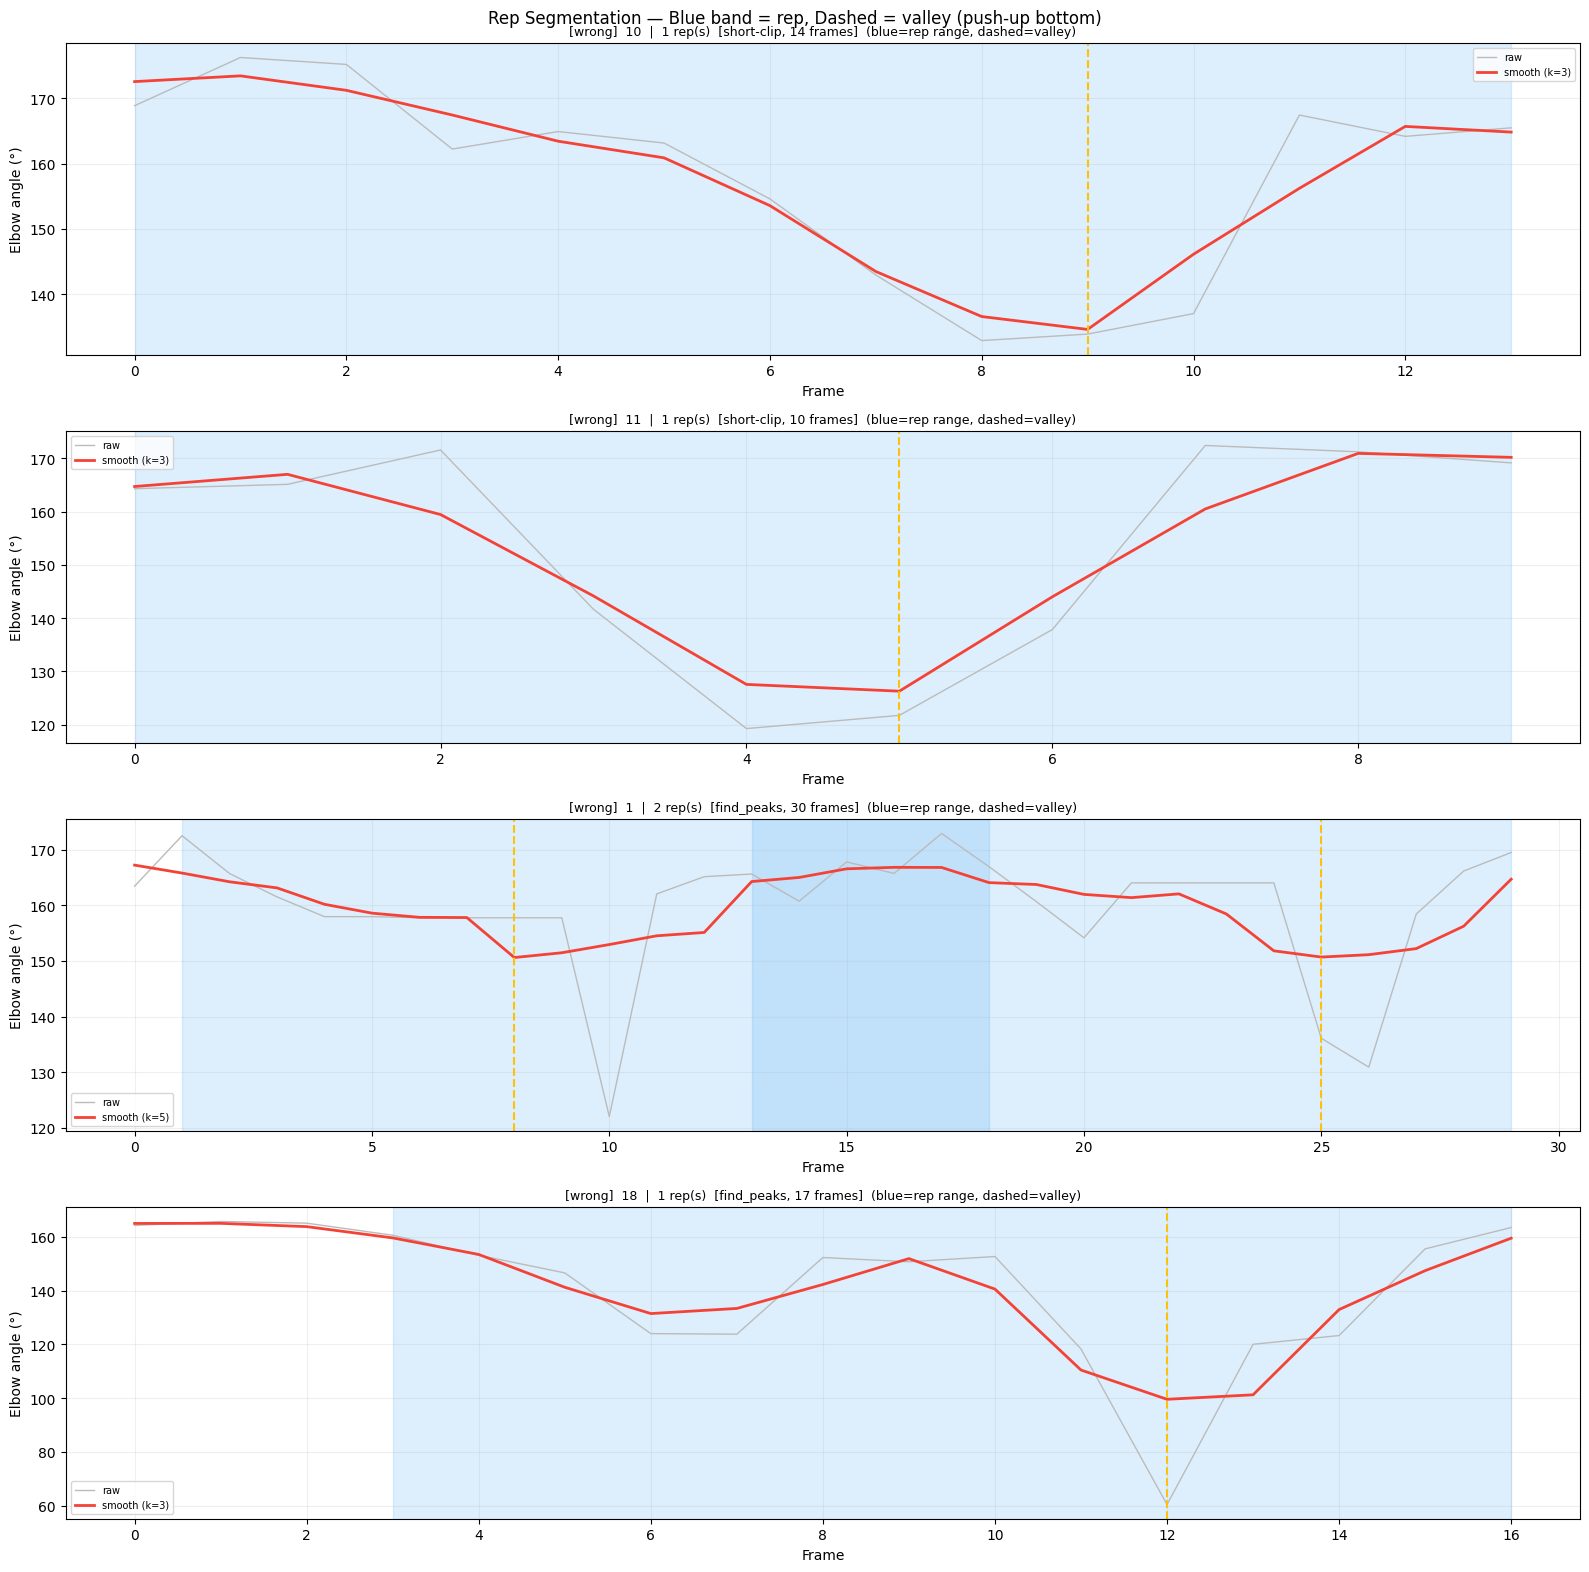

In [48]:

def plot_rep_segments(feat_data: dict, ax=None, **kwargs):
    segs  = extract_rep_segments(feat_data, **kwargs)
    feats = feat_data['features']
    raw   = np.array([f['mean_elbow_angle'] for f in feats])
    k_use = adaptive_k(len(raw), kwargs.get('k', SMOOTH_K))
    smo   = moving_average(raw, k=k_use)

    if ax is None:
        _, ax = plt.subplots(figsize=(16, 4))

    color = '#4CAF50' if feat_data['label'] == 'correct' else '#F44336'
    ax.plot(raw, color='#BBB', lw=1, label='raw')
    ax.plot(smo, color=color,  lw=2, label=f'smooth (k={k_use})')

    for seg in segs:
        ax.axvspan(seg['start'], seg['end'] - 1, alpha=0.15, color='#2196F3')
        ax.axvline(seg['valley'], color='#FFC107', lw=1.5, ls='--')

    n_fr = len(feats)
    mode = 'short-clip' if n_fr < SHORT_CLIP_THRESHOLD else 'find_peaks'
    ax.set_title(
        f'[{feat_data["label"]}]  {feat_data["video"]}  |  '
        f'{len(segs)} rep(s)  [{mode}, {n_fr} frames]  '
        f'(blue=rep range, dashed=valley)',
        fontsize=9)
    ax.set_ylabel('Elbow angle (°)')
    ax.set_xlabel('Frame')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)
    return segs


# Visualise sample — include a short clip if available
short_files = [f for f in feat_files
               if len(json.loads(f.read_text())['features']) < SHORT_CLIP_THRESHOLD]
long_files  = [f for f in feat_files
               if len(json.loads(f.read_text())['features']) >= SHORT_CLIP_THRESHOLD]

# Mix short + long for a representative display
vis_sample = (short_files[:2] + long_files[:2])[:4]
if not vis_sample:
    vis_sample = sample

n_vis = len(vis_sample)
fig, axes = plt.subplots(n_vis, 1, figsize=(16, 4 * n_vis))
if n_vis == 1:
    axes = [axes]
for ax, jf in zip(axes, vis_sample):
    vd = load_features(jf)
    plot_rep_segments(vd, ax=ax)

plt.suptitle('Rep Segmentation — Blue band = rep, Dashed = valley (push-up bottom)',
             fontsize=12)
plt.tight_layout()
plt.show()


### ⚠ Manual Inspection Checkpoint

Before continuing, verify that:
1. Each blue band captures exactly **one push-up** (down AND up).
2. The yellow dashed line sits at the **lowest point** of the arm bend.
3. No obvious rep is **missed** or **split in two**.

If not, adjust `DISTANCE` / `PROMINENCE` in cell 2.4 and re-run the plots.

## 2.7 Bulk Segmentation — All Videos

In [49]:
all_segs  = []
seg_stats = []
n_no_reps = 0

for jf in tqdm(sorted(FEAT_DIR.glob('*.json')), desc='Segmenting'):
    vd   = load_features(jf)
    segs = extract_rep_segments(vd)

    if not segs:
        n_no_reps += 1
        print(f'  WARNING: 0 reps detected in {vd["video"]} [{vd["label"]}]')
        continue

    # Save segment file
    out_path = SEG_DIR / f'{jf.stem}.json'
    out_path.write_text(json.dumps(segs))

    all_segs.extend(segs)
    seg_stats.append({
        'video'  : vd['video'],
        'label'  : vd['label'],
        'n_reps' : len(segs),
        'min_len': min(s['length'] for s in segs),
        'max_len': max(s['length'] for s in segs),
        'mean_len': round(np.mean([s['length'] for s in segs]), 1),
    })

df_segs = pd.DataFrame(seg_stats)
print(f'\nVideos with ≥1 rep : {len(df_segs)}')
print(f'Videos with 0 reps : {n_no_reps}')
print(f'Total reps extracted: {len(all_segs)}')
print()
print('Per-label summary:')
print(df_segs.groupby('label')[['n_reps', 'mean_len', 'min_len', 'max_len']].describe().round(1))

Segmenting: 100%|██████████| 152/152 [00:00<00:00, 1760.89it/s]


Videos with ≥1 rep : 152
Videos with 0 reps : 0
Total reps extracted: 157

Per-label summary:
        n_reps                                    mean_len        ... min_len  \
         count mean  std  min  25%  50%  75%  max    count  mean  ...     75%   
label                                                             ...           
correct   76.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0     76.0  10.1  ...    12.0   
wrong     76.0  1.1  0.2  1.0  1.0  1.0  1.0  2.0     76.0  11.8  ...    14.0   

              max_len                                         
          max   count  mean  std  min  25%   50%   75%   max  
label                                                         
correct  16.0    76.0  10.1  2.8  6.0  8.0  10.0  12.0  16.0  
wrong    20.0    76.0  11.9  3.7  6.0  9.0  12.0  14.0  20.0  

[2 rows x 32 columns]


## 2.8 Rep Length Distribution

Angle range < 5°  (very flat signal) : 3 videos
Angle range 5–15°                    : 1 videos
Angle range ≥ 15°                    : 148 videos

10 smallest-range videos (hardest to segment):
              video   label  n_frames  angle_range  angle_min  angle_max
            right24 correct         6          0.0      155.1      155.1
            right22 correct         7          0.7      163.4      164.1
            right23 correct         6          4.0      155.5      159.5
 Copy_of_push_up_81   wrong        12          7.1      156.2      163.3
 Copy_of_push_up_85 correct         8         15.2      146.7      161.9
 Copy_of_push_up_79 correct         6         15.5      160.2      175.8
Copy_of_push_up_166   wrong        22         16.5      149.3      165.8
                  1   wrong        30         16.6      150.6      167.2
             wrong9   wrong         6         17.5      139.9      157.4
                  3   wrong        12         18.2      151.1      169.3


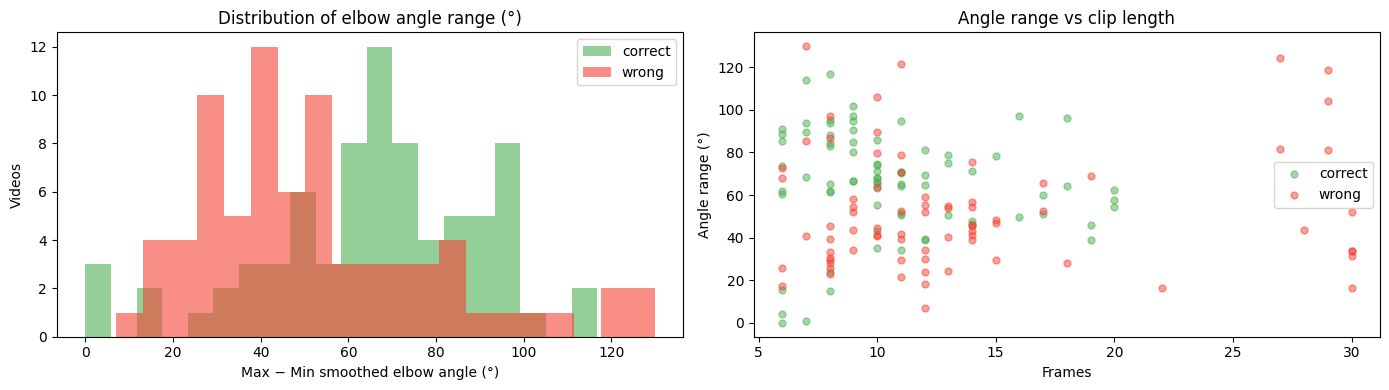

In [50]:

# ── Diagnose videos that still produced only the last-resort single valley ────
# Show signal range (max - min elbow angle) for ALL videos to understand
# how much angular variation exists.
signal_ranges = []
for jf in sorted(FEAT_DIR.glob('*.json')):
    vd   = load_features(jf)
    raw  = np.array([f['mean_elbow_angle'] for f in vd['features']])
    smo  = moving_average(raw)
    rng  = float(smo.max() - smo.min())
    signal_ranges.append({
        'video'  : vd['video'],
        'label'  : vd['label'],
        'n_frames': len(raw),
        'angle_range': round(rng, 1),
        'angle_min'  : round(float(smo.min()), 1),
        'angle_max'  : round(float(smo.max()), 1),
    })

df_sig = pd.DataFrame(signal_ranges).sort_values('angle_range')

print(f'Angle range < 5°  (very flat signal) : {(df_sig.angle_range < 5).sum()} videos')
print(f'Angle range 5–15°                    : {((df_sig.angle_range>=5)&(df_sig.angle_range<15)).sum()} videos')
print(f'Angle range ≥ 15°                    : {(df_sig.angle_range >= 15).sum()} videos')
print()
print('10 smallest-range videos (hardest to segment):')
print(df_sig.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, c in [('correct','#4CAF50'), ('wrong','#F44336')]:
    sub = df_sig[df_sig.label == label]
    axes[0].hist(sub.angle_range, bins=20, alpha=0.6, color=c, label=label)
    axes[1].scatter(sub.n_frames, sub.angle_range, alpha=0.5, color=c, label=label, s=25)
axes[0].set_title('Distribution of elbow angle range (°)')
axes[0].set_xlabel('Max − Min smoothed elbow angle (°)')
axes[0].set_ylabel('Videos'); axes[0].legend()
axes[1].set_title('Angle range vs clip length')
axes[1].set_xlabel('Frames'); axes[1].set_ylabel('Angle range (°)'); axes[1].legend()
plt.tight_layout()
plt.show()


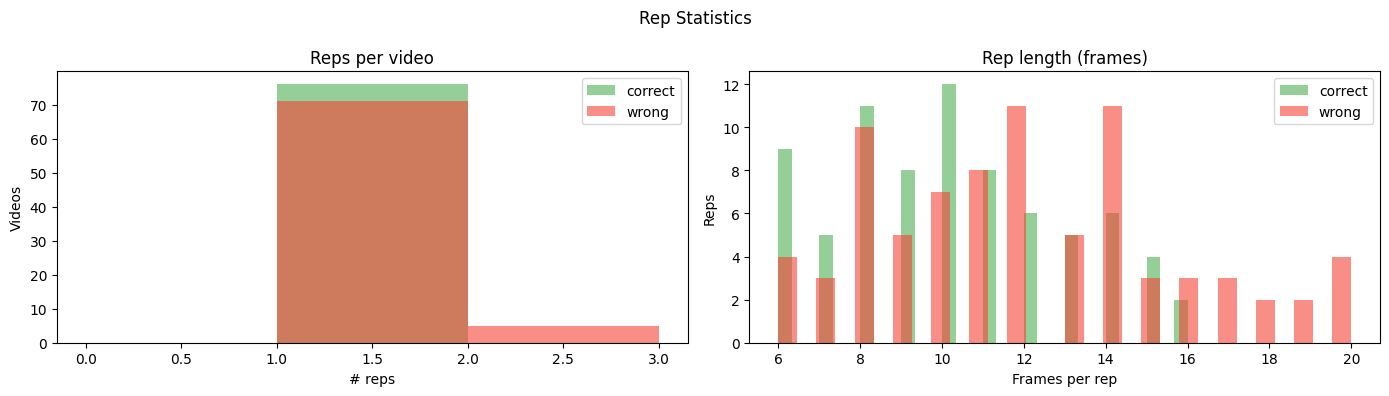

Rep length percentiles:  p10=7  p50=11  p90=15
Recommended T_fixed = p75 = 14


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rep count per video
for label, c in [('correct', '#4CAF50'), ('wrong', '#F44336')]:
    sub = df_segs[df_segs.label == label]
    axes[0].hist(sub.n_reps, bins=range(0, sub.n_reps.max()+2),
                 alpha=0.6, color=c, label=label)
axes[0].set_title('Reps per video')
axes[0].set_xlabel('# reps'); axes[0].set_ylabel('Videos')
axes[0].legend()

# Rep length (frames)
for label, c in [('correct', '#4CAF50'), ('wrong', '#F44336')]:
    lengths = [s['length'] for s in all_segs if s['label'] == label]
    axes[1].hist(lengths, bins=30, alpha=0.6, color=c, label=label)
axes[1].set_title('Rep length (frames)')
axes[1].set_xlabel('Frames per rep'); axes[1].set_ylabel('Reps')
axes[1].legend()

plt.suptitle('Rep Statistics', fontsize=12)
plt.tight_layout()
plt.show()

# Recommend T_fixed
all_lengths = [s['length'] for s in all_segs]
p10, p50, p90 = np.percentile(all_lengths, [10, 50, 90])
print(f'Rep length percentiles:  p10={p10:.0f}  p50={p50:.0f}  p90={p90:.0f}')
print(f'Recommended T_fixed = p75 = {int(np.percentile(all_lengths, 75))}')

## 2.9 Save Segmentation Config

In [52]:
all_lengths = [s['length'] for s in all_segs]
cfg = {
    'smooth_k'   : SMOOTH_K,
    'distance'   : DISTANCE,
    'prominence' : PROMINENCE,
    'padding'    : 3,
    'n_videos'   : len(df_segs),
    'n_reps'     : len(all_segs),
    'label_counts': {
        label: len([s for s in all_segs if s['label'] == label])
        for label in ['correct', 'wrong']
    },
    'rep_length_p10' : int(np.percentile(all_lengths, 10)),
    'rep_length_p50' : int(np.percentile(all_lengths, 50)),
    'rep_length_p75' : int(np.percentile(all_lengths, 75)),
    'rep_length_p90' : int(np.percentile(all_lengths, 90)),
    'suggested_T_fixed': int(np.percentile(all_lengths, 75)),
}

cfg_path = FE_DIR / 'data' / 'seg_config.json'
cfg_path.write_text(json.dumps(cfg, indent=2))

print(f'Saved: {cfg_path}')
print(json.dumps(cfg, indent=2))

Saved: /Users/haleytran/Downloads/pushup_judge/feature_engineering/data/seg_config.json
{
  "smooth_k": 5,
  "distance": 8,
  "prominence": 5,
  "padding": 3,
  "n_videos": 152,
  "n_reps": 157,
  "label_counts": {
    "correct": 76,
    "wrong": 81
  },
  "rep_length_p10": 7,
  "rep_length_p50": 11,
  "rep_length_p75": 14,
  "rep_length_p90": 15,
  "suggested_T_fixed": 14
}


## 2.10 Summary

| Artifact | Location |
|---|---|
| Per-video segment JSONs | `feature_engineering/data/segments/{video}.json` |
| Segmentation config | `feature_engineering/data/seg_config.json` |

Each segment JSON: list of rep dicts with `features`, `label`, `start/end/valley/length`.

**Next:** `3.resampling_and_dataset.ipynb` — interpolate every rep to `T_fixed` frames and build the LSTM dataset.